In [18]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
warnings.filterwarnings('ignore')

In [ ]:
# !pip install holidays

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.8 MB/s eta 0:00:00


In [2]:
target_station = ['ST-1035','ST-454','ST-471']

In [ ]:
df = pd.read_csv('../../Data/Zero/2024_data.csv')

df = df.sort_values(['시작_대여소_ID','기준_날짜','시간대'])

df = df.iloc[:,[i for i in range(df.shape[1]) if i != 2]]
df


,기준_날짜,시간대,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
27038,2025-04-04,21,ST-10,ST-454,1.0,3300,9035.0,7.3,71,47.19117,0.0,0.0
27055,2025-04-04,21,ST-10,ST-454,1.0,3300,9035.0,7.3,71,47.19117,0.0,0.0
40169,2025-04-29,21,ST-10,ST-454,1.0,3180,8630.0,10.9,62,52.95342,0.0,0.0
40185,2025-04-29,21,ST-10,ST-454,1.0,3180,8630.0,10.9,62,52.95342,0.0,0.0
46014,2025-05-11,22,ST-10,ST-454,1.0,3480,9047.0,11.5,93,52.90405,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
70218,2025-06-18,18,ST-991,ST-454,1.0,2940,7052.0,26.5,51,73.85185,0.0,0.0
22146,2025-03-25,17,ST-992,ST-454,1.0,3780,14144.0,12.9,54,55.92334,0.0,0.0
22160,2025-03-25,17,ST-992,ST-454,1.0,3780,14144.0,12.9,54,55.92334,0.0,0.0
155123,2025-12-12,13,ST-997,ST-454,2.0,9360,26487.0,4.8,37,46.65524,0.0,0.0


In [46]:
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])

df['요일'] = df['기준_날짜'].dt.dayofweek

df['day_type'] = df['요일'].apply(
    lambda x: 'weekday' if x < 5 else 'weekend'
)
kr = holidays.KR()

df['is_holiday'] = df['기준_날짜'].dt.date.isin(kr)

df['day_type'] = np.where(
    (df['요일'] >= 5) | (df['is_holiday']),
    'weekend',
    'weekday'
)
df

,기준_날짜,시간대,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량,요일,day_type,is_holiday
27038,2025-04-04,21,ST-10,ST-454,1.0,3300,9035.0,7.3,71,47.19117,0.0,0.0,4,weekday,False
27055,2025-04-04,21,ST-10,ST-454,1.0,3300,9035.0,7.3,71,47.19117,0.0,0.0,4,weekday,False
40169,2025-04-29,21,ST-10,ST-454,1.0,3180,8630.0,10.9,62,52.95342,0.0,0.0,1,weekday,False
40185,2025-04-29,21,ST-10,ST-454,1.0,3180,8630.0,10.9,62,52.95342,0.0,0.0,1,weekday,False
46014,2025-05-11,22,ST-10,ST-454,1.0,3480,9047.0,11.5,93,52.90405,0.0,0.0,6,weekend,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70218,2025-06-18,18,ST-991,ST-454,1.0,2940,7052.0,26.5,51,73.85185,0.0,0.0,2,weekday,False
22146,2025-03-25,17,ST-992,ST-454,1.0,3780,14144.0,12.9,54,55.92334,0.0,0.0,1,weekday,False
22160,2025-03-25,17,ST-992,ST-454,1.0,3780,14144.0,12.9,54,55.92334,0.0,0.0,1,weekday,False
155123,2025-12-12,13,ST-997,ST-454,2.0,9360,26487.0,4.8,37,46.65524,0.0,0.0,4,weekday,False


In [16]:
pattern = df.groupby(
    ['시작_대여소_ID','day_type','시간대']
)['전체_건수'].mean().reset_index()
pattern

,시작_대여소_ID,day_type,시간대,전체_건수
0,ST-1020,weekday,0,1.000000
1,ST-1020,weekday,1,1.000000
2,ST-1020,weekday,2,1.000000
3,ST-1020,weekday,6,1.000000
4,ST-1020,weekday,7,1.000000
...,...,...,...,...
3615,ST-93,weekend,17,1.333333
3616,ST-93,weekend,18,1.142857
3617,ST-93,weekend,19,1.000000
3618,ST-93,weekend,20,1.000000


==================== 
Month

In [15]:
monthly = df.groupby(
    [df['기준_날짜'].dt.month,'시간대']
)['전체_건수'].mean()
monthly

기준_날짜  시간대
1      0      1.018135
       1      1.022472
       2      1.011407
       3      1.025862
       4      1.020408
                ...   
12     19     1.029260
       20     1.024590
       21     1.017949
       22     1.013587
       23     1.041475
Name: 전체_건수, Length: 288, dtype: float64

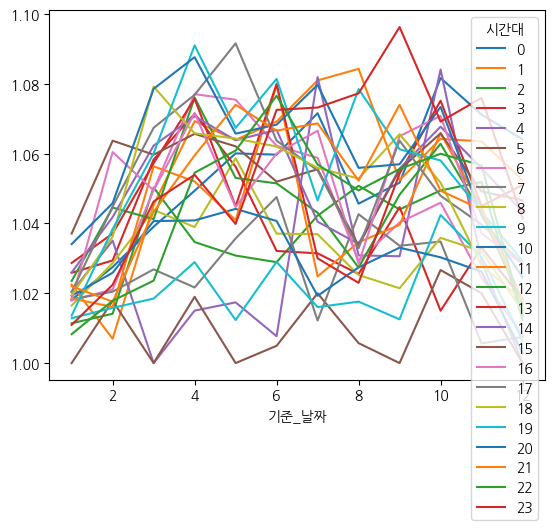

In [ ]:
monthly.unstack().plot()
plt.show()

================ Week

In [20]:
weekly = df.groupby(
    ['요일','시간대']
)['전체_건수'].mean()

<Axes: xlabel='시간대'>

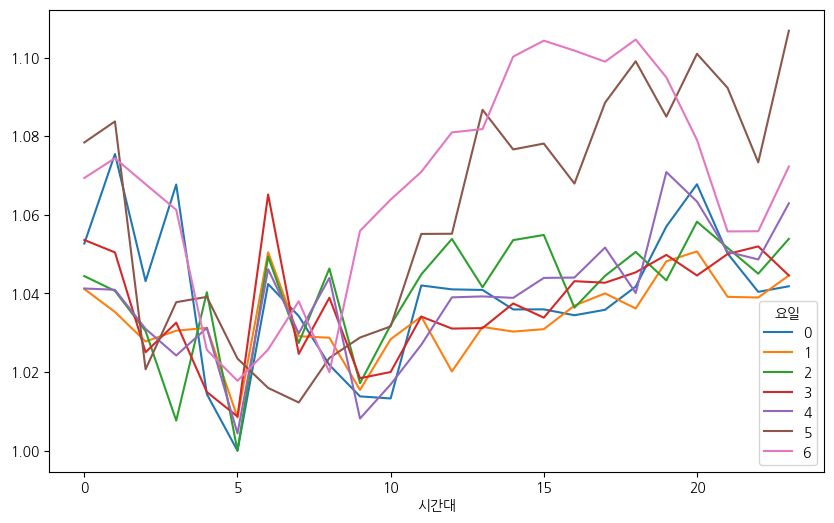

In [22]:
weekly = df.groupby(
    ['요일','시간대']
)['전체_건수'].mean().unstack()

weekly.T.plot(figsize=(10,6))

<Axes: xlabel='시간대'>

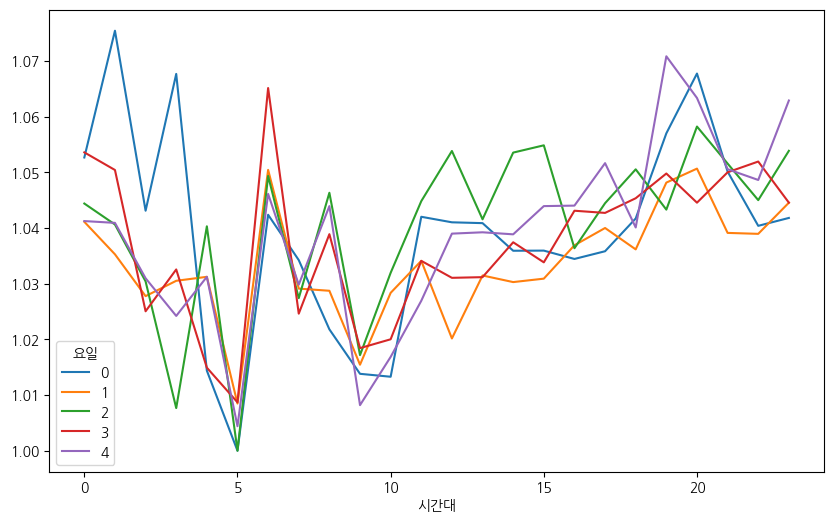

In [27]:
weekday = weekly.iloc[:4+1,:]

weekday.T.plot(figsize=(10,6))

<Axes: xlabel='시간대'>

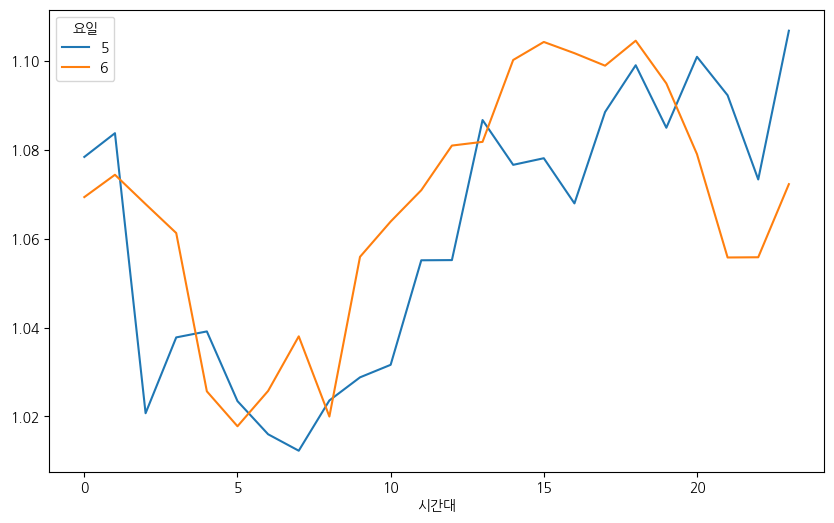

In [28]:
weekend = weekly.iloc[5:,:]

weekend.T.plot(figsize=(10,6))

============

In [30]:
pattern = df.groupby(
    ['day_type','시간대']
)['전체_건수'].mean()
pattern

day_type  시간대
weekday   0      1.046312
          1      1.047885
          2      1.031095
          3      1.030511
          4      1.026499
          5      1.004303
          6      1.050952
          7      1.029033
          8      1.036581
          9      1.014308
          10     1.021984
          11     1.036064
          12     1.036887
          13     1.036910
          14     1.038961
          15     1.040049
          16     1.039151
          17     1.043174
          18     1.042561
          19     1.053983
          20     1.056665
          21     1.048280
          22     1.045301
          23     1.050420
weekend   0      1.073998
          1      1.079545
          2      1.043774
          3      1.048942
          4      1.032328
          5      1.020790
          6      1.020513
          7      1.022371
          8      1.022371
          9      1.040156
          10     1.046721
          11     1.061838
          12     1.066349
          13     1.08437

In [32]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array(weekday.index).reshape(-1,1)   # 시간대
y = weekday.mean(axis=1).values             # 평균 이용량

model_weekday = LinearRegression()
model_weekday.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
X = np.array(weekend.index).reshape(-1,1)
y = weekend.mean(axis=1).values

model_weekend = LinearRegression()
model_weekend.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
print(model_weekday.coef_, model_weekday.intercept_)

[0.00030273] 1.037321422685292


===================

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model_weekday = make_pipeline(
    PolynomialFeatures(3),
    LinearRegression()
)

model_weekday.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


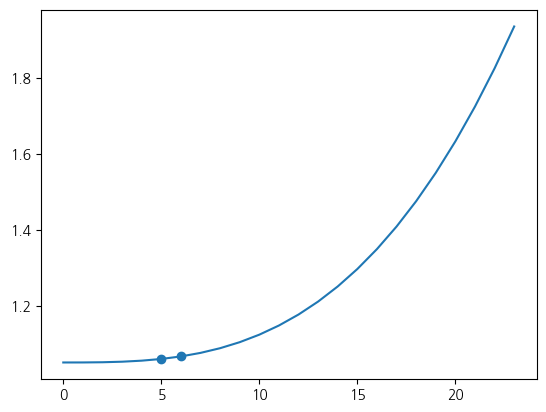

In [37]:
x_plot = np.arange(0,24)

y_pred = model_weekday.predict(x_plot.reshape(-1,1))

plt.scatter(X,y)
plt.plot(x_plot,y_pred)
plt.show()

=================

In [38]:
import pandas as pd
import numpy as np

df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])

# 요일
df['weekday'] = df['기준_날짜'].dt.dayofweek

# 평일 / 주말
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)

# feature
features = [
    '시간대',
    'day_type',
    '온도',
    '습도',
    '불쾌지수',
    '강수량',
    '적설량'
]

target = '전체_건수'

In [39]:
train = df[df['기준_날짜'].dt.year == 2024]
test  = df[df['기준_날짜'].dt.year == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [41]:
train

,기준_날짜,시간대,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량,요일,day_type,is_holiday,weekday
1192,2024-01-04,8,ST-1020,ST-454,1.0,960,2547.0,-4.8,88,25.64624,0.0,0.0,3,0,False,3
1204,2024-01-04,8,ST-1020,ST-454,1.0,960,2547.0,-4.8,88,25.64624,0.0,0.0,3,0,False,3
7005,2024-01-23,0,ST-1020,ST-454,1.0,1320,2658.0,-12.9,41,24.75189,0.0,0.0,1,0,False,1
7007,2024-01-23,0,ST-1020,ST-454,1.0,1320,2658.0,-12.9,41,24.75189,0.0,0.0,1,0,False,1
7060,2024-01-23,8,ST-1020,ST-454,1.0,1020,2473.0,-15.1,41,22.07691,0.0,0.0,1,0,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184639,2024-12-23,12,ST-93,ST-1035,1.0,1860,5625.0,1.0,48,40.72120,0.0,0.0,0,0,False,0
185047,2024-12-24,17,ST-93,ST-454,1.0,1620,5339.0,-1.1,46,38.33006,0.0,0.0,1,0,False,1
185076,2024-12-24,17,ST-93,ST-454,1.0,1620,5339.0,-1.1,46,38.33006,0.0,0.0,1,0,False,1
186597,2024-12-30,11,ST-93,ST-454,1.0,2100,5449.0,6.1,66,45.78874,0.0,0.0,0,0,False,0
